# 2 - Model Training

This notebook trains the CNN model on the MNIST dataset and visualizes the training process.

## 0 - Imports

In [13]:
import sys
import os

sys.path.append(os.path.join(os.path.abspath(""), "..", "src"))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from data_loader import load_data, preprocess_data
from evaluate import plot_training_history
from model import build_model
from train import train

## 1 - Data loading and preprocessing

In [14]:
(X_train, y_train), (X_test, y_test) = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(X_train, y_train, X_test, y_test)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (60000, 28, 28, 1)
X_test  : (10000, 28, 28, 1)


## 2 - Summary

In [15]:
model = build_model()
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

### Convolution effect

Correct prediction


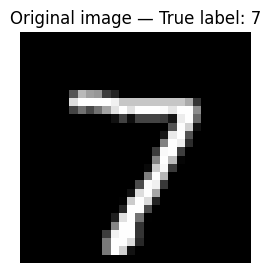

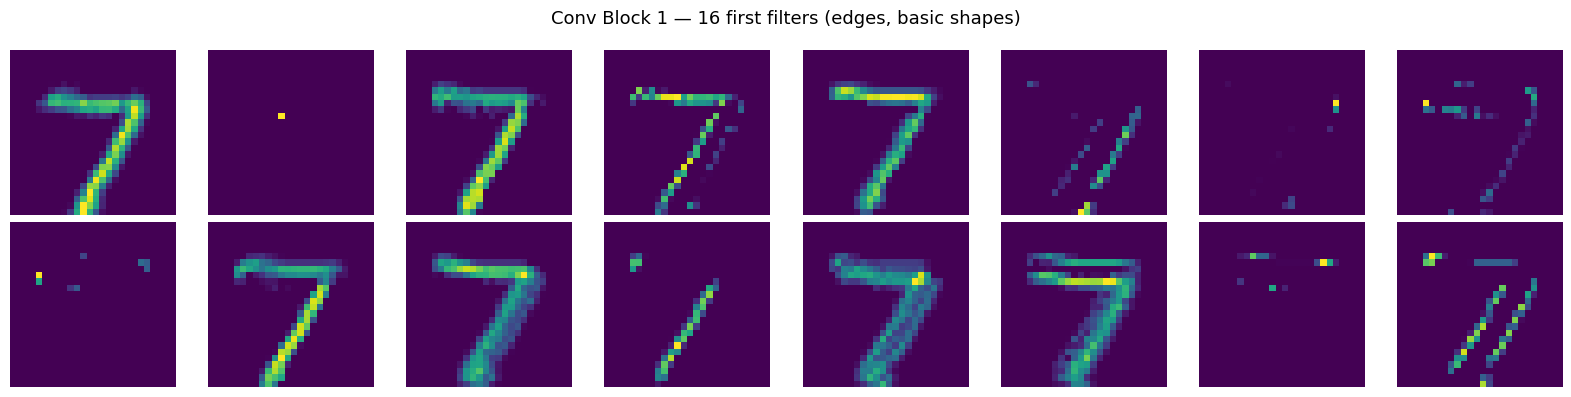

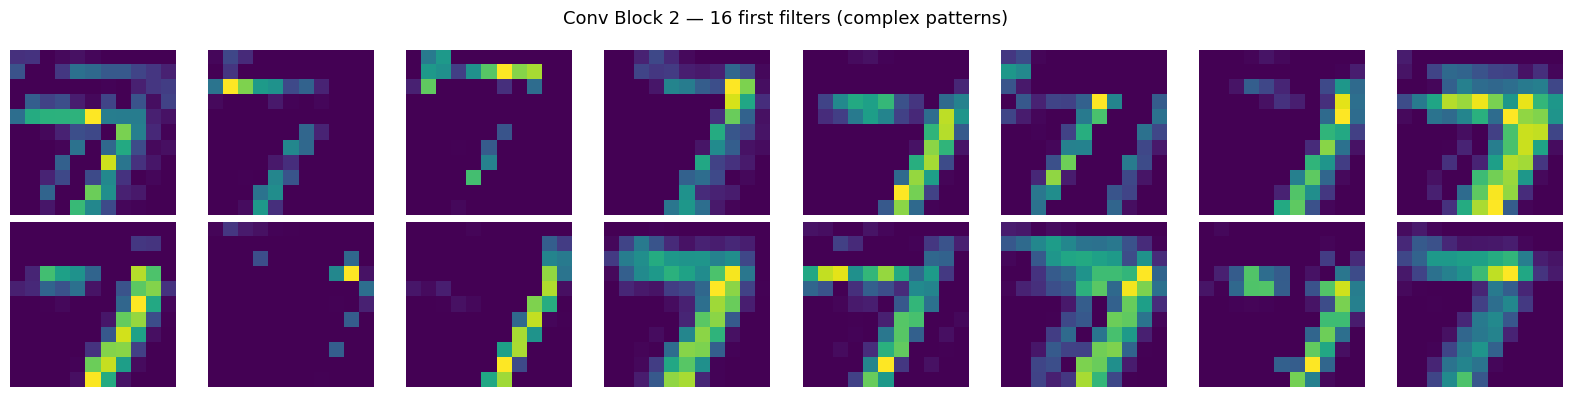

Incorrect prediction


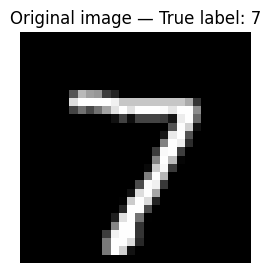

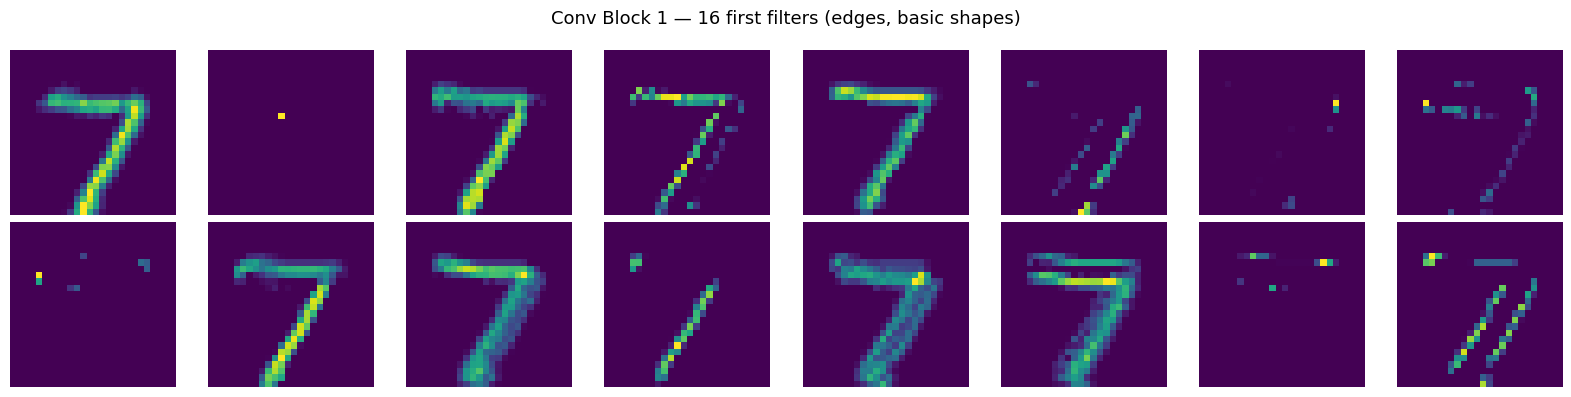

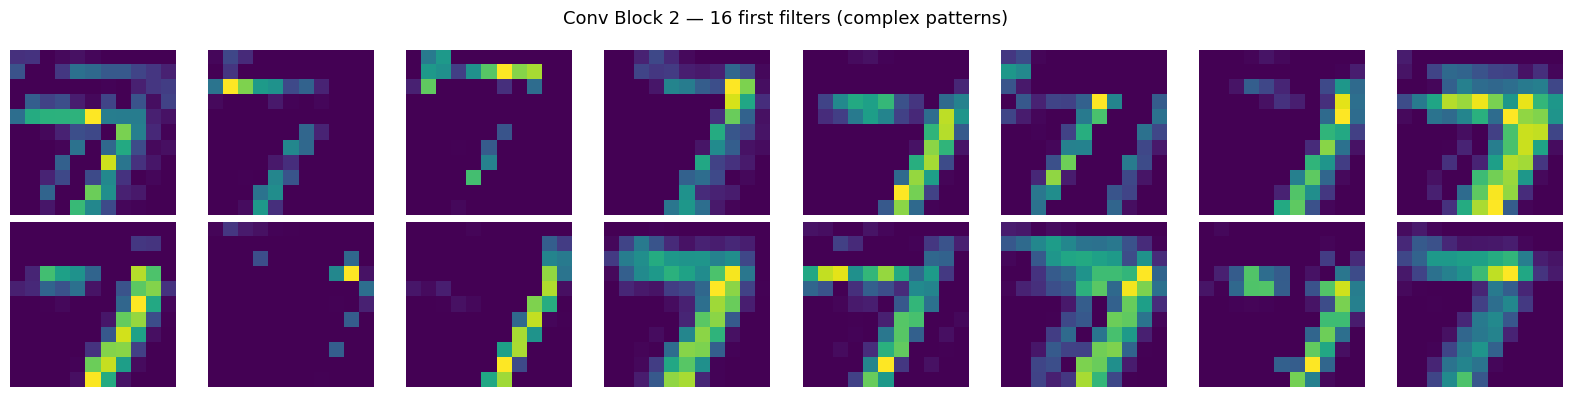

In [16]:
def plot_activations(idx):
    image = X_test[idx]

    # Build activation models for both conv layers
    input_layer = tf.keras.Input(shape = (28, 28, 1))
    x = input_layer
    for layer in model.layers:
        x = layer(x)
        if layer == model.layers[0]:
            output_conv1 = x
        if layer == model.layers[4]:
            output_conv2 = x

    conv1_model = tf.keras.Model(inputs = input_layer, outputs = output_conv1)
    conv2_model = tf.keras.Model(inputs = input_layer, outputs = output_conv2)

    input_img         = image.reshape(1, 28, 28, 1)
    activations_conv1 = conv1_model.predict(input_img, verbose = 0)
    activations_conv2 = conv2_model.predict(input_img, verbose = 0)

    def plot_filters(activations, title, n_filters = 16):
        fig, axes = plt.subplots(2, 8, figsize = (16, 4))
        fig.suptitle(title, fontsize = 13)
        for i, ax in enumerate(axes.flat):
            if i < n_filters:
                ax.imshow(activations[0, :, :, i], cmap = "viridis")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # Original image
    plt.figure(figsize = (3, 3))
    plt.imshow(image.reshape(28, 28), cmap = "gray")
    plt.title(f"Original image — True label: {y_true_cls[idx]}")
    plt.axis("off")
    plt.show()

    plot_filters(activations_conv1, "Conv Block 1 — 16 first filters (edges, basic shapes)")
    plot_filters(activations_conv2, "Conv Block 2 — 16 first filters (complex patterns)")


# Pick a random test image
y_pred_cls = np.argmax(model.predict(X_test, verbose = 0), axis = 1)
y_true_cls = np.argmax(y_test, axis = 1)
incorrect_idx = np.where(y_pred_cls != y_true_cls)[0]

# Show activations for a correct and an incorrect prediction
print("Correct prediction")
plot_activations(0)

print("Incorrect prediction")
plot_activations(incorrect_idx[0])

## 3 - Training

In [17]:
model, history = train()

Epoch 1/20
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8117 - auc: 0.9661 - loss: 0.6462 - precision: 0.8645 - recall: 0.7723
Epoch 1: val_accuracy improved from None to 0.98333, saving model to c:\Users\Ledge\cnn-mnist\outputs\models\best_model.keras

Epoch 1: finished saving model to c:\Users\Ledge\cnn-mnist\outputs\models\best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9015 - auc: 0.9908 - loss: 0.3268 - precision: 0.9295 - recall: 0.8824 - val_accuracy: 0.9833 - val_auc: 0.9990 - val_loss: 0.0582 - val_precision: 0.9851 - val_recall: 0.9818 - learning_rate: 0.0010
Epoch 2/20
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9594 - auc: 0.9969 - loss: 0.1395 - precision: 0.9674 - recall: 0.9534
Epoch 2: val_accuracy did not improve from 0.98333
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9611 - auc: 0.9971 - loss: 0.1309 - precision: 0.9679 - recall: 0.9562 - val_accuracy: 0.9830 - val_auc: 0.9986 - val_loss: 0.0578 - val_prec

## 4 - Training history

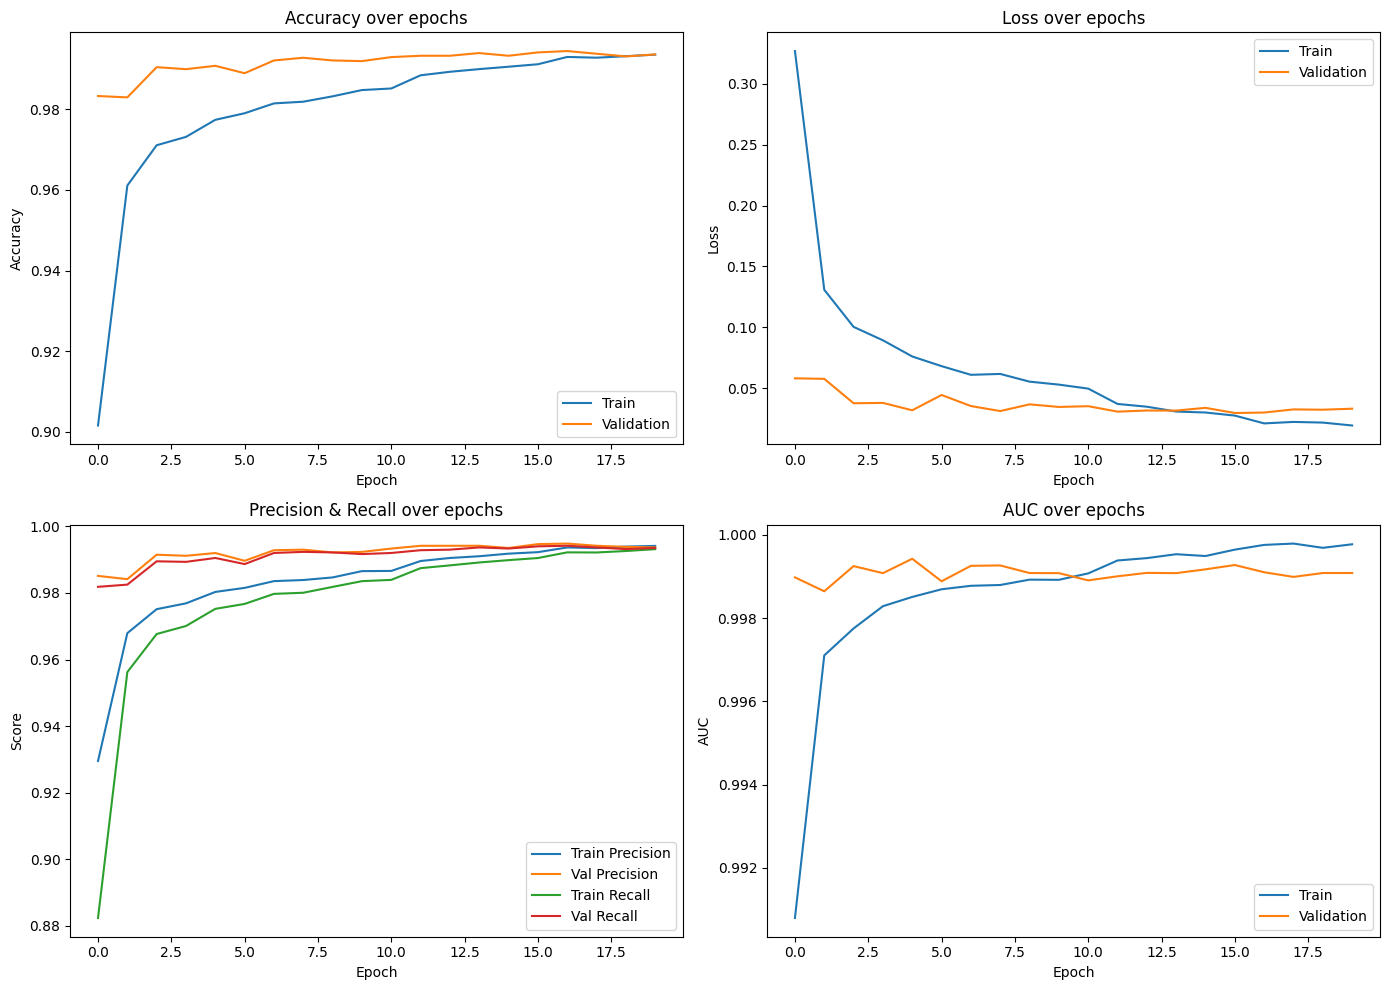

In [18]:
plot_training_history(history)